In [1]:
import pandas as pd

data = pd.read_csv("data\Evolución_enfermedad_fiebre_de_Norilsk.csv")


<>:3: SyntaxWarning: invalid escape sequence '\E'
<>:3: SyntaxWarning: invalid escape sequence '\E'
C:\Users\felip\AppData\Local\Temp\ipykernel_40320\4052520467.py:3: SyntaxWarning: invalid escape sequence '\E'
  data = pd.read_csv("data\Evolución_enfermedad_fiebre_de_Norilsk.csv")


In [2]:
data

,Unnamed: 0,Semana 1,Unnamed: 2,Unnamed: 3,Semana 2,Unnamed: 5,Unnamed: 6,Semana 3,Unnamed: 8,Unnamed: 9
0,NaN,Susceptible,Infectados,Muertos,Susceptible,Infectados,Muertos,Susceptible,Infectados,Muertos
1,Norilsk,200000,300,0,200000,1500,300,200000,5000,650
2,Kayerkan,80000,10,0,80000,700,120,80000,2300,1000
3,Dudinka,60000,20,0,60000,1200,60,60000,3000,900


In [4]:
data.columns = ['Ubicación', 'Susceptible_S1', 'Infectados_S1', 'Muertos_S1', 
              'Susceptible_S2', 'Infectados_S2', 'Muertos_S2', 
              'Susceptible_S3', 'Infectados_S3', 'Muertos_S3']


In [5]:
data

,Ubicación,Susceptible_S1,Infectados_S1,Muertos_S1,Susceptible_S2,Infectados_S2,Muertos_S2,Susceptible_S3,Infectados_S3,Muertos_S3
0,NaN,Susceptible,Infectados,Muertos,Susceptible,Infectados,Muertos,Susceptible,Infectados,Muertos
1,Norilsk,200000,300,0,200000,1500,300,200000,5000,650
2,Kayerkan,80000,10,0,80000,700,120,80000,2300,1000
3,Dudinka,60000,20,0,60000,1200,60,60000,3000,900


In [6]:
data.shape

(4, 10)

In [7]:

# Elimina la fila con nombres de columnas duplicadas
data = data.drop(index=0).reset_index(drop=True)

# Convierte columnas numéricas a enteros
cols = data.columns[1:]  # excepto 'Ubicación'
data[cols] = data[cols].astype(int)

In [10]:
data.to_excel('data/dataframe_fiebre.xlsx', index=False)

# Data

In [11]:
data = pd.read_excel('data/dataframe_fiebre.xlsx')

In [12]:
data

,Ubicación,Susceptible_S1,Infectados_S1,Muertos_S1,Susceptible_S2,Infectados_S2,Muertos_S2,Susceptible_S3,Infectados_S3,Muertos_S3
0,Norilsk,200000,300,0,200000,1500,300,200000,5000,650
1,Kayerkan,80000,10,0,80000,700,120,80000,2300,1000
2,Dudinka,60000,20,0,60000,1200,60,60000,3000,900


In [19]:
import pandas as pd



# Tasa de recuperación estimada
rec_rate = 0.3 / 0.7

# Calcular recuperados
data["Recuperados_S1"] = 0
data["Recuperados_S2"] = (rec_rate * data["Muertos_S2"]).astype(int)
data["Recuperados_S3"] = (rec_rate * data["Muertos_S3"]).astype(int)

# Reordenar columnas
column_order = [
    "Ubicación",
    "Susceptible_S1", "Infectados_S1", "Muertos_S1", "Recuperados_S1",
    "Susceptible_S2", "Infectados_S2", "Muertos_S2", "Recuperados_S2",
    "Susceptible_S3", "Infectados_S3", "Muertos_S3", "Recuperados_S3"
]

data = data[column_order]

# Mostrar el DataFrame final ordenado
print(data)


  Ubicación  Susceptible_S1  Infectados_S1  Muertos_S1  Recuperados_S1  \
0   Norilsk          200000            300           0               0   
1  Kayerkan           80000             10           0               0   
2   Dudinka           60000             20           0               0   

   Susceptible_S2  Infectados_S2  Muertos_S2  Recuperados_S2  Susceptible_S3  \
0          200000           1500         300             128          200000   
1           80000            700         120              51           80000   
2           60000           1200          60              25           60000   

   Infectados_S3  Muertos_S3  Recuperados_S3  
0           5000         650             278  
1           2300        1000             428  
2           3000         900             385  


In [23]:
data

,Ubicación,Susceptible_S1,Infectados_S1,Muertos_S1,Recuperados_S1,Susceptible_S2,Infectados_S2,Muertos_S2,Recuperados_S2,Susceptible_S3,Infectados_S3,Muertos_S3,Recuperados_S3
0,Norilsk,200000,300,0,0,200000,1500,300,128,200000,5000,650,278
1,Kayerkan,80000,10,0,0,80000,700,120,51,80000,2300,1000,428
2,Dudinka,60000,20,0,0,60000,1200,60,25,60000,3000,900,385


In [40]:
# Paso 1: Agregar las columnas Removidos_S1, S2, S3
for semana in [1, 2, 3]:
    col_muertos = f'Muertos_S{semana}'
    col_recuperados = f'Recuperados_S{semana}'
    col_removidos = f'Removidos_S{semana}'
    data[col_removidos] = data[col_muertos] + data[col_recuperados]

# Paso 2: Reordenar columnas por semana
orden_columnas = ['Ubicación']
for semana in [1, 2, 3]:
    orden_columnas += [
        f'Susceptible_S{semana}',
        f'Infectados_S{semana}',
        f'Muertos_S{semana}',
        f'Recuperados_S{semana}',
        f'Removidos_S{semana}'
    ]

# Aplicar el nuevo orden
data = data[orden_columnas]


In [ ]:
# data.to_excel('data/dataframe_fiebre_final.xlsx', index=False)

In [43]:
data

,Ubicación,Susceptible_S1,Infectados_S1,Muertos_S1,Recuperados_S1,Removidos_S1,Susceptible_S2,Infectados_S2,Muertos_S2,Recuperados_S2,Removidos_S2,Susceptible_S3,Infectados_S3,Muertos_S3,Recuperados_S3,Removidos_S3
0,Norilsk,200000,300,0,0,0,200000,1500,300,128,428,200000,5000,650,278,928
1,Kayerkan,80000,10,0,0,0,80000,700,120,51,171,80000,2300,1000,428,1428
2,Dudinka,60000,20,0,0,0,60000,1200,60,25,85,60000,3000,900,385,1285


# ***


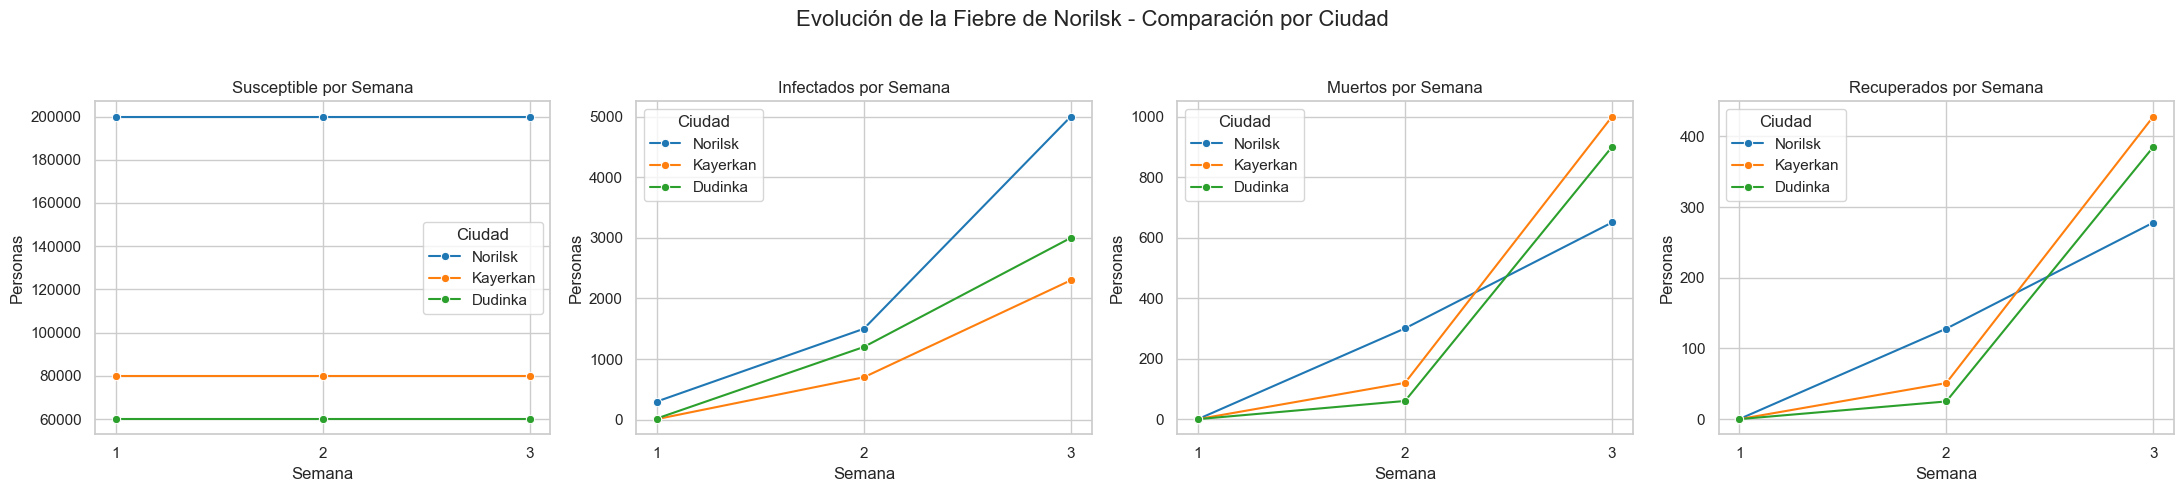

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Reorganizar en formato largo
df_long = data.melt(id_vars='Ubicación', var_name='Variable', value_name='Cantidad')
df_long['Semana'] = df_long['Variable'].str.extract(r'S(\d)').astype(int)
df_long['Tipo'] = df_long['Variable'].str.extract(r'([A-Za-z]+)')

# Configurar estilo
sns.set(style='whitegrid')
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharex=True)

# Paleta de colores por ciudad
city_palette = {'Norilsk': '#1f77b4', 'Kayerkan': '#ff7f0e', 'Dudinka': '#2ca02c'}

# Plot por cada tipo (incluye Recuperados)
for ax, tipo in zip(axes, ['Susceptible', 'Infectados', 'Muertos', 'Recuperados']):
    df_tipo = df_long[df_long['Tipo'] == tipo]
    sns.lineplot(
        data=df_tipo, x='Semana', y='Cantidad',
        hue='Ubicación', palette=city_palette,
        marker='o', ax=ax
    )
    ax.set_title(f'{tipo} por Semana')
    ax.set_xlabel('Semana')
    ax.set_ylabel('Personas')
    ax.set_xticks([1, 2, 3])
    ax.legend().set_title('Ciudad')

fig.suptitle('Evolución de la Fiebre de Norilsk - Comparación por Ciudad', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# MOdelos SIR

In [35]:
res.x[0]

0.43077819903355447

In [36]:
t

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
       52., 53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.,
       65., 66., 67., 68., 69., 70.])

In [37]:
data

,Ubicación,Susceptible_S1,Infectados_S1,Muertos_S1,Recuperados_S1,Susceptible_S2,Infectados_S2,Muertos_S2,Recuperados_S2,Susceptible_S3,Infectados_S3,Muertos_S3,Recuperados_S3
0,Norilsk,200000,300,0,0,200000,1500,300,128,200000,5000,650,278
1,Kayerkan,80000,10,0,0,80000,700,120,51,80000,2300,1000,428
2,Dudinka,60000,20,0,0,60000,1200,60,25,60000,3000,900,385


β estimado para Norilsk: 0.2710


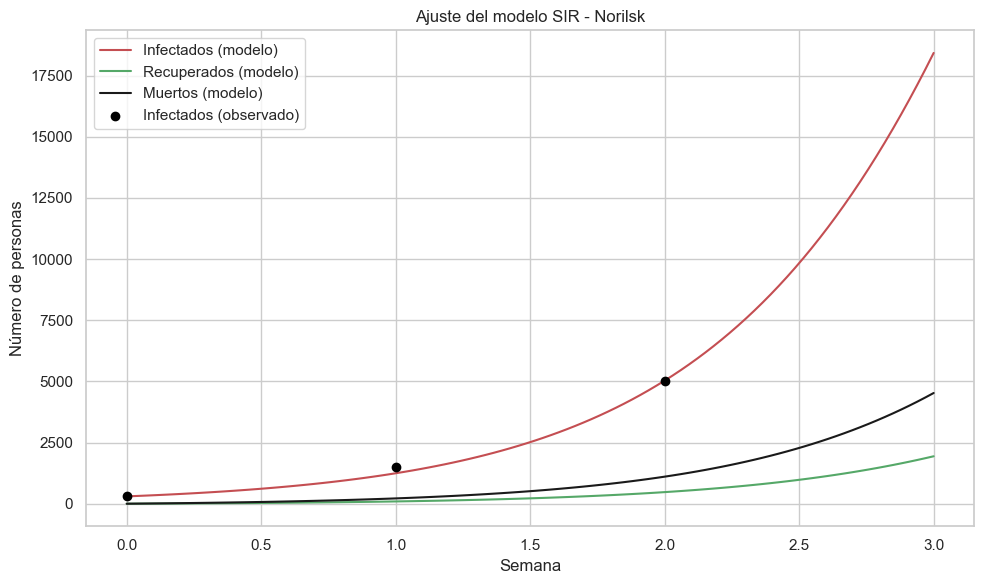

β estimado para Kayerkan: 0.4586


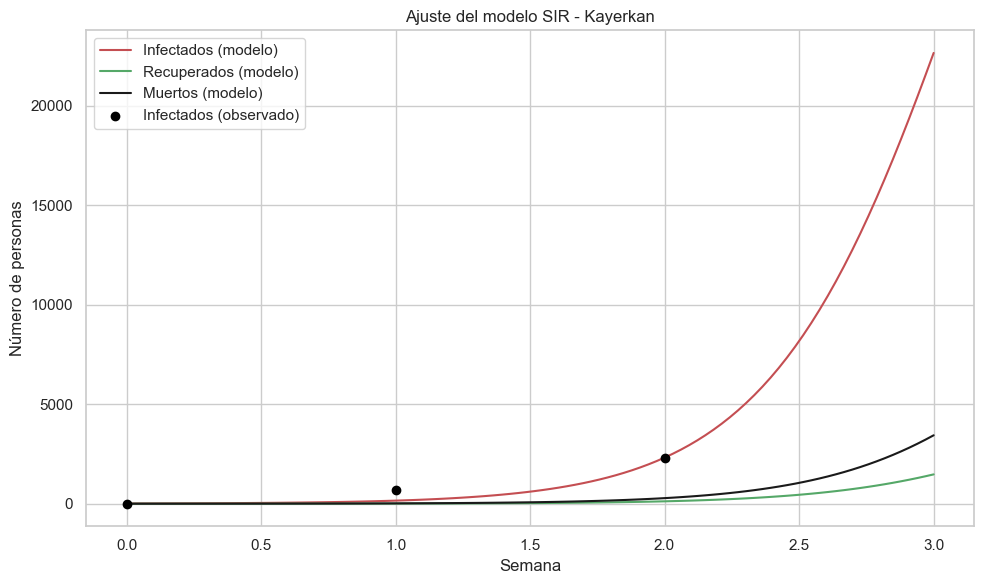

β estimado para Dudinka: 0.4308


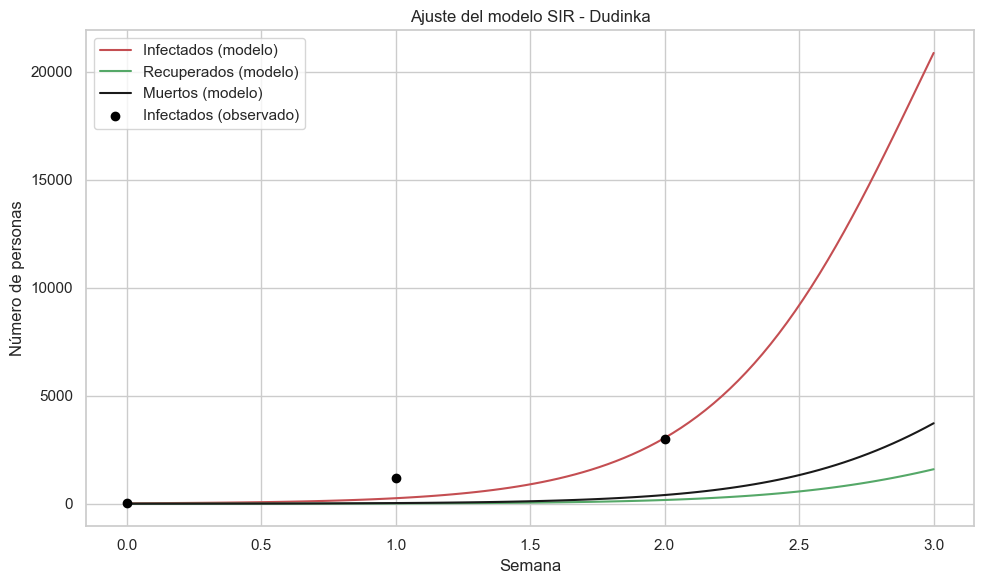

In [44]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Parámetros globales
gamma = 1/15  # fija
dias_por_semana = 7
semanas = 3
t = np.linspace(0, dias_por_semana * (semanas - 1), semanas)  # t = [0, 7, 14]

# Modelo SIR
def deriv(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I    
    return dSdt, dIdt, dRdt

# Recorrer las ciudades
for idx, row in data.iterrows():
    ciudad = row['Ubicación']
    
    # Datos observados
    infectados_obs = np.array([
        row['Infectados_S1'],
        row['Infectados_S2'],
        row['Infectados_S3']
    ])
    
    # Condiciones iniciales
    S0 = row['Susceptible_S1']
    I0 = row['Infectados_S1']
    R0 = row['Removidos_S1']  # ← usar los removidos reales desde semana 1
    N = S0 + I0 + R0
    y0 = (S0, I0, R0)

    # Función objetivo para ajustar beta
    def objective(beta_array):
        beta = beta_array[0]
        ret = odeint(deriv, y0, t, args=(N, beta, gamma))
        I_pred = ret[:, 1]
        return np.sum((I_pred - infectados_obs) ** 2)

    # Estimar beta
    res = minimize(objective, x0=[0.2], bounds=[(0.001, 1.0)])
    beta_est = res.x[0]
    print(f"β estimado para {ciudad}: {beta_est:.4f}")
    
    # Simulación completa
    t_full = np.linspace(0, 21, 100)
    sol = odeint(deriv, y0, t_full, args=(N, beta_est, gamma))
    S, I, R = sol.T

    # Separar R en muertos (70%) y recuperados (30%)
    R_muertos = 0.7 * R
    R_recuperados = 0.3 * R

    # Gráfica
    plt.figure(figsize=(10, 6))
    plt.plot(t_full / 7, I, 'r-', label='Infectados (modelo)')
    plt.plot(t_full / 7, R_recuperados, 'g-', label='Recuperados (modelo)')
    plt.plot(t_full / 7, R_muertos, 'k-', label='Muertos (modelo)')
    plt.scatter([0, 1, 2], infectados_obs, color='black', label='Infectados (observado)', zorder=5)
    plt.xlabel('Semana')
    plt.ylabel('Número de personas')
    plt.title(f'Ajuste del modelo SIR - {ciudad}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Norilsk: β = 0.2710, R₀ = 4.07


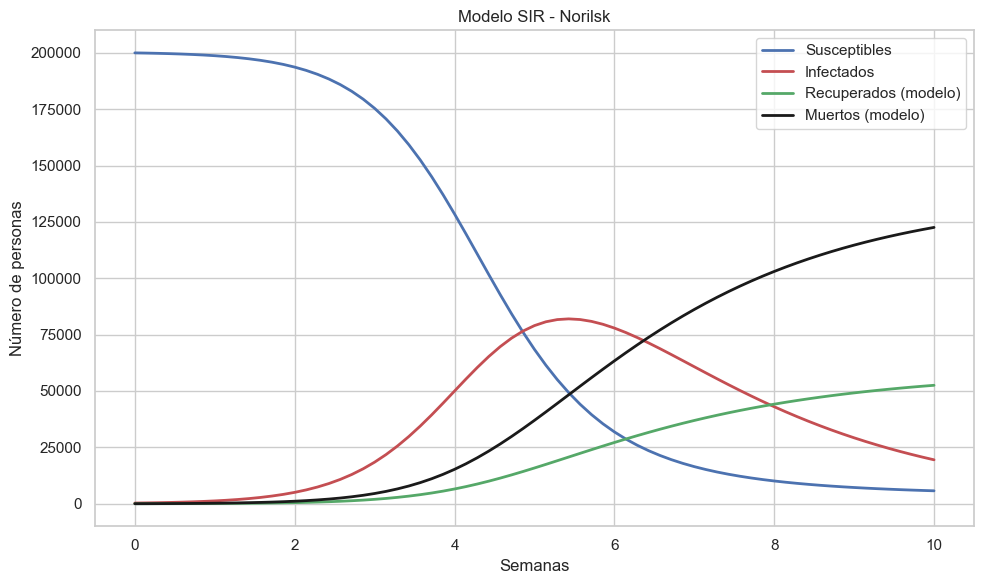

Kayerkan: β = 0.4586, R₀ = 6.88


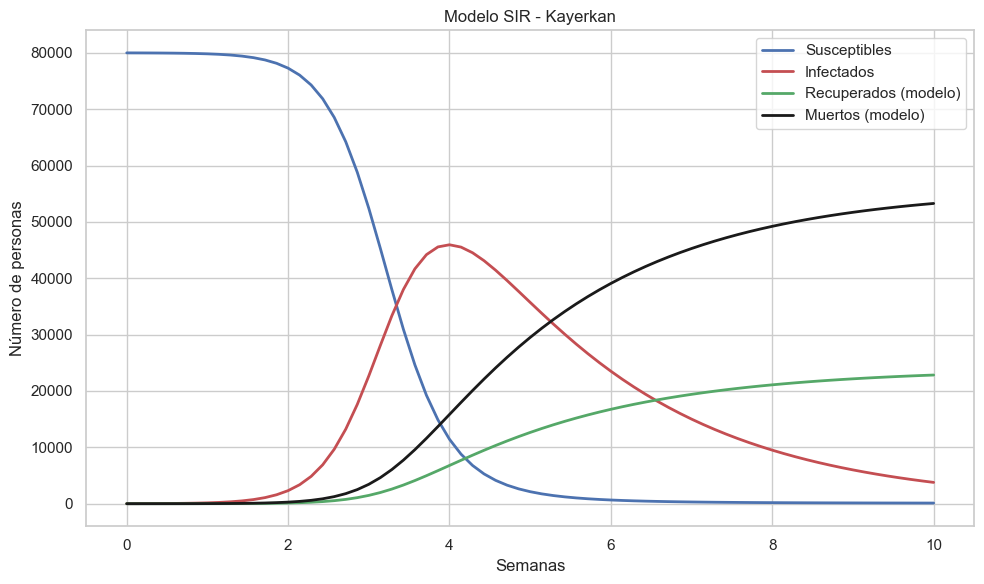

Dudinka: β = 0.4308, R₀ = 6.46


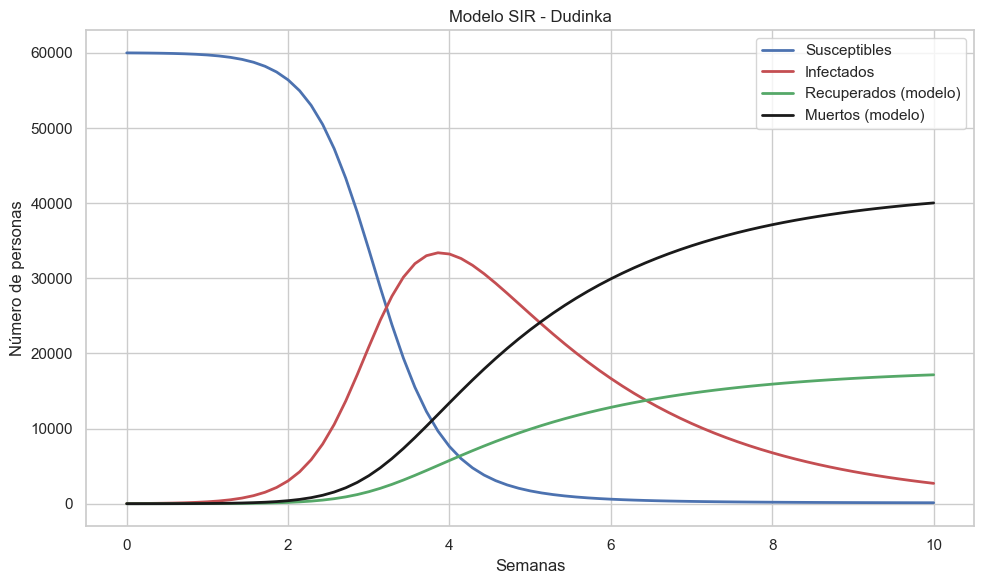

In [45]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Diccionario de betas estimadas
betas_estimadas = {
    'Norilsk': 0.2710,
    'Kayerkan': 0.4586,
    'Dudinka': 0.4308
}

gamma = 1 / 15  # Tasa de recuperación
duracion_dias = 70  # 10 semanas

# Modelo SIR
def deriv(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# Simulación para cada ciudad
for idx, row in data.iterrows():
    ciudad = row['Ubicación']
    beta = betas_estimadas[ciudad]
    R0_val = beta / gamma
    print(f"{ciudad}: β = {beta:.4f}, R₀ = {R0_val:.2f}")
    
    # Condiciones iniciales usando Removidos reales
    S0 = row['Susceptible_S1']
    I0 = row['Infectados_S1']
    R0_init = row['Removidos_S1']  # <- removidos iniciales (muertos + recuperados)
    N = S0 + I0 + R0_init
    y0 = (S0, I0, R0_init)

    # Tiempo
    t = np.linspace(0, duracion_dias, duracion_dias + 1)

    # Integrar el modelo
    sol = odeint(deriv, y0, t, args=(N, beta, gamma))
    S, I, R = sol.T

    # Separar R en muertos (70%) y recuperados (30%)
    R_muertos = 0.7 * R
    R_recuperados = 0.3 * R

    # Gráfica
    plt.figure(figsize=(10, 6))
    plt.plot(t / 7, S, 'b', lw=2, label='Susceptibles')
    plt.plot(t / 7, I, 'r', lw=2, label='Infectados')
    plt.plot(t / 7, R_recuperados, 'g', lw=2, label='Recuperados (modelo)')
    plt.plot(t / 7, R_muertos, 'k', lw=2, label='Muertos (modelo)')
    plt.title(f'Modelo SIR - {ciudad}')
    plt.xlabel('Semanas')
    plt.ylabel('Número de personas')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Modelo SIR

β estimado para Norilsk: 0.2710


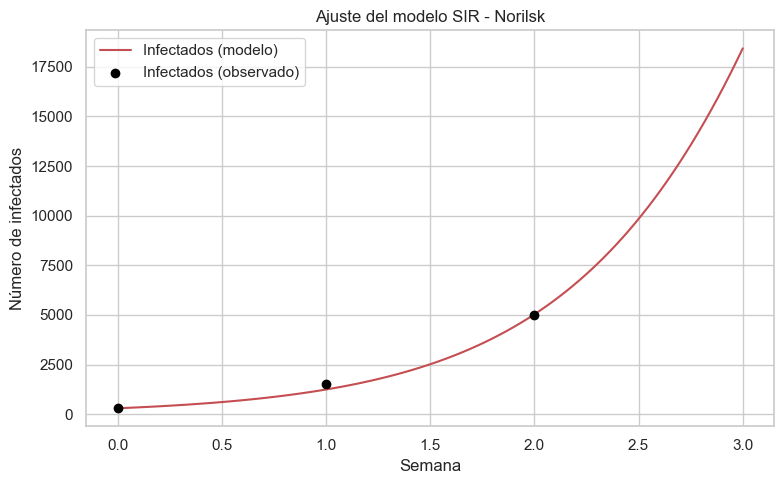

β estimado para Kayerkan: 0.4586


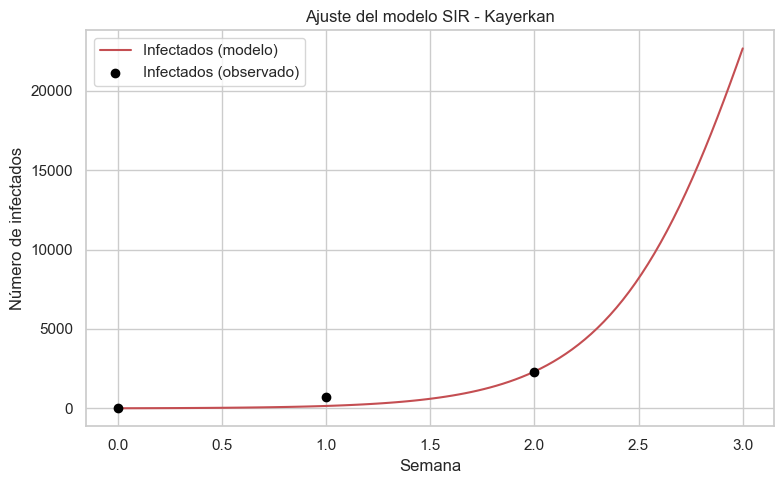

β estimado para Dudinka: 0.4308


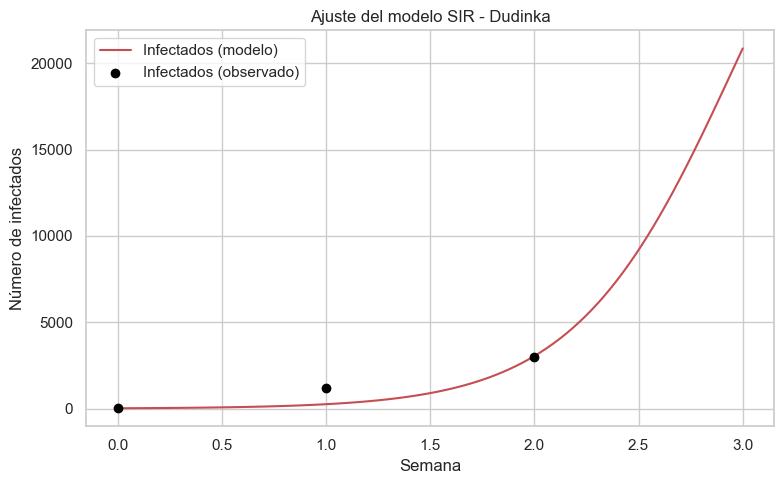

In [14]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
from scipy.optimize import minimize
import matplotlib.pyplot as plt


# Parámetros globales
gamma = 1/15  # fija
dias_por_semana = 7
semanas = 3
t = np.linspace(0, dias_por_semana * (semanas - 1), semanas)  # t en días: 0, 7, 14

# Modelo SIR
def deriv(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I    
    return dSdt, dIdt, dRdt

# Recorrer las ciudades
for idx, row in data.iterrows():
    ciudad = row['Ubicación']
    
    # Datos observados de infectados (S1, S2, S3)
    infectados_obs = np.array([
        row['Infectados_S1'],
        row['Infectados_S2'],
        row['Infectados_S3']
    ])
    
    # Condiciones iniciales
    S0 = row['Susceptible_S1']
    I0 = row['Infectados_S1']
    R0 = 0
    D0 = row['Muertos_S1']
    N = S0 + I0 + R0 + D0
    y0 = (S0, I0, R0)
    
    # Función objetivo
    def objective(beta_array):
        beta = beta_array[0]
        ret = odeint(deriv, y0, t, args=(N, beta, gamma))
        I_pred = ret[:, 1]
        return np.sum((I_pred - infectados_obs) ** 2)
    
    # Optimización
    res = minimize(objective, x0=[0.2], bounds=[(0.001, 1.0)])
    beta_est = res.x[0]
    print(f"β estimado para {ciudad}: {beta_est:.4f}")
    
    # Simulación completa
    t_full = np.linspace(0, 21, 100)  # 3 semanas (21 días)
    sol = odeint(deriv, y0, t_full, args=(N, beta_est, gamma))
    S, I, R = sol.T

    # Gráfica
    plt.figure(figsize=(8, 5))
    plt.plot(t_full / 7, I, 'r-', label='Infectados (modelo)')
    plt.scatter([0, 1, 2], infectados_obs, color='black', label='Infectados (observado)', zorder=5)
    plt.xlabel('Semana')
    plt.ylabel('Número de infectados')
    plt.title(f'Ajuste del modelo SIR - {ciudad}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Norilsk: β = 0.2710, R₀ = 4.07


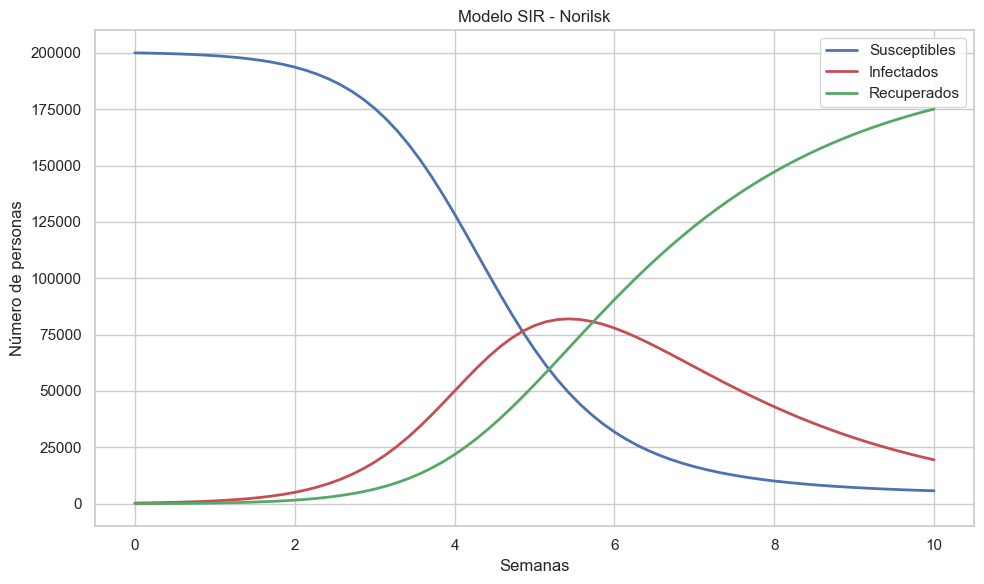

Kayerkan: β = 0.4586, R₀ = 6.88


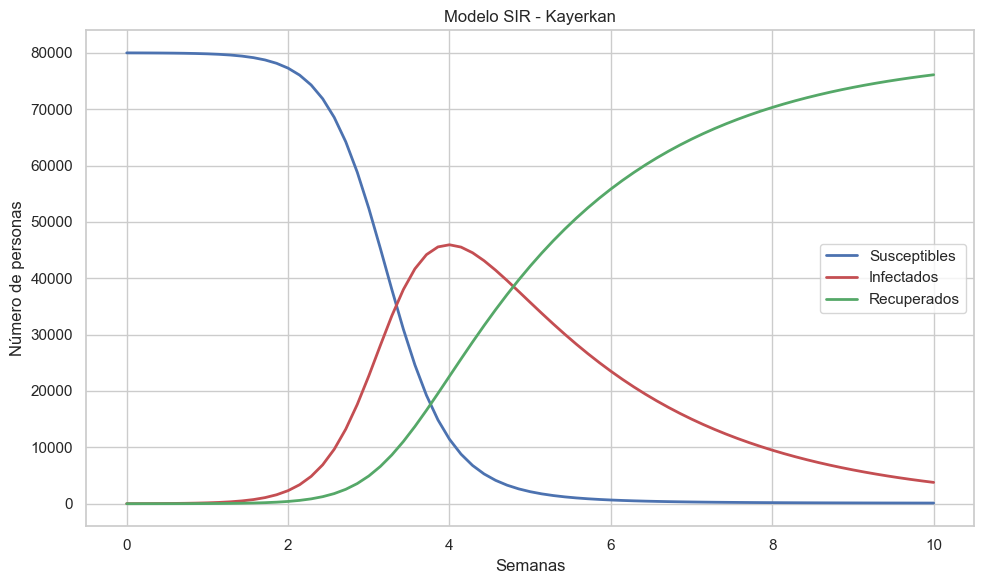

Dudinka: β = 0.4308, R₀ = 6.46


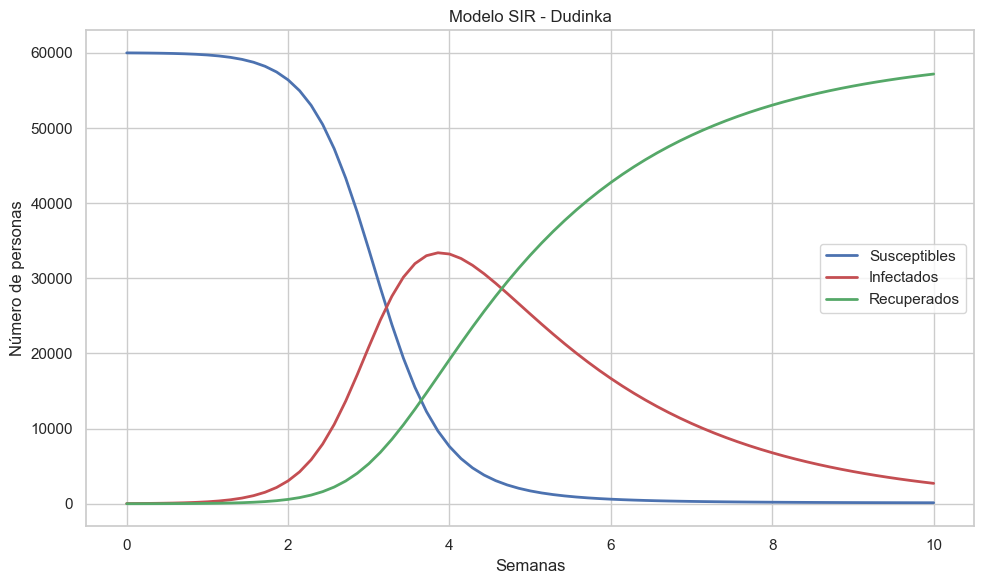

In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Diccionario de betas estimadas
betas_estimadas = {
    'Norilsk': 0.2710,
    'Kayerkan': 0.4586,
    'Dudinka': 0.4308
}

gamma = 1 / 15  # Tasa de recuperación (15 días)
duracion_dias = 70  # Duración de simulación (10 semanas)

# Modelo SIR
def deriv(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# Simulación para cada ciudad
for idx, row in data.iterrows():
    ciudad = row['Ubicación']
    beta = betas_estimadas[ciudad]
    R0_val = beta / gamma
    print(f"{ciudad}: β = {beta:.4f}, R₀ = {R0_val:.2f}")
    
    # Condiciones iniciales
    S0 = row['Susceptible_S1']
    I0 = row['Infectados_S1']
    R0_init = 0
    D0 = row['Muertos_S1']
    N = S0 + I0 + R0_init + D0
    y0 = (S0, I0, R0_init)

    # Tiempo
    t = np.linspace(0, duracion_dias, duracion_dias + 1)

    # Integrar el modelo
    sol = odeint(deriv, y0, t, args=(N, beta, gamma))
    S, I, R = sol.T

    # Gráfica
    plt.figure(figsize=(10, 6))
    plt.plot(t / 7, S, 'b', lw=2, label='Susceptibles')
    plt.plot(t / 7, I, 'r', lw=2, label='Infectados')
    plt.plot(t / 7, R, 'g', lw=2, label='Recuperados')
    plt.title(f'Modelo SIR - {ciudad}')
    plt.xlabel('Semanas')
    plt.ylabel('Número de personas')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
